# 🎵 Spotify Tracks — Exploratory Data Analysis
**Author:** Anvi Poshia  
**Dataset:** 114,000 Spotify tracks across 114 genres  
**Goal:** Explore what makes a song popular and how audio features relate to each other.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style="darkgrid")

# Load the dataset
df = pd.read_csv('dataset.csv')
print("Dataset loaded!")
print(f"Shape: {df.shape}")
df.head()

Dataset loaded!
Shape: (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 📦 Dataset Overview
The dataset contains 114,000 songs with 20 features including audio characteristics 
like energy, danceability, and acousticness, along with metadata like artist, genre, and popularity score.

In [2]:
#More information about the dataset
df.info()

# Statistics about the dataset
df.describe()

#Number of duplicates
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

0

In [12]:
# Remove any row with atleast one Nan
df_clean = df.dropna()

print(df_clean.shape)

#Unique genres
unique_genres = df_clean['track_genre'].nunique()
print("Unique Genres", unique_genres) 

(113999, 20)
Unique Genres 114


## 🧹 Data Cleaning
Dropped 1 row with missing values (artists/album/track name). 
The dataset is largely clean with no duplicates, leaving us with 113,999 songs across 114 unique genres.

## 📊 Popularity Distribution
How popular are most songs on Spotify? Popularity is scored 0–100 by Spotify based on total streams and recency.

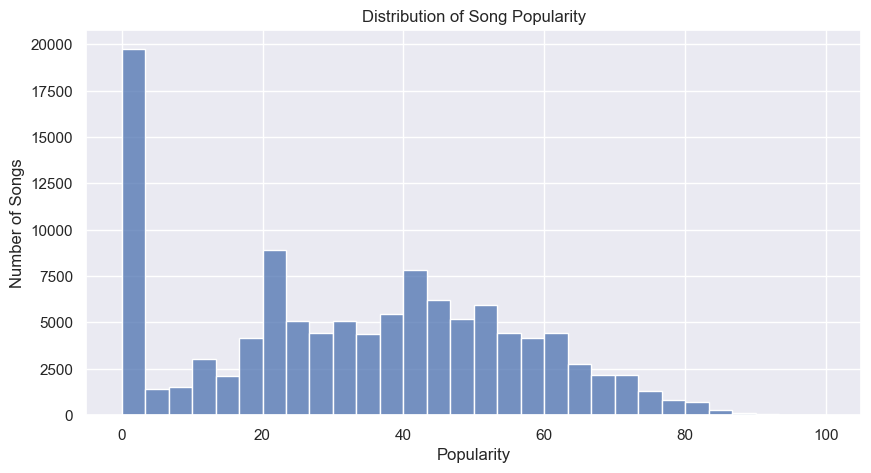

In [14]:
# Popularity Distribution : How popular are most songs among Spotify
plt.figure(figsize=(10, 5))
sns.histplot(df_clean, x='popularity', bins = 30)
plt.title("Distribution of Song Popularity")
plt.xlabel("Popularity")
plt.ylabel("Number of Songs")
plt.show()

> **Insight:** The distribution is right-skewed — nearly 20,000 songs have zero popularity. 
Viral success is rare and concentrated among a small fraction of tracks. 
Most songs on Spotify are simply never discovered.

## 🎸 Top 10 Most Popular Genres
Which genres have the highest average popularity scores across all their tracks?

Top 10   track_genre  popularity
0    pop-film   59.283000
1       k-pop   56.952953
2       chill   53.651000
3         sad   52.379000
4      grunge   49.594000
5      indian   49.539000
6       anime   48.772000
7         emo   48.128000
8   sertanejo   47.866000
9         pop   47.576000


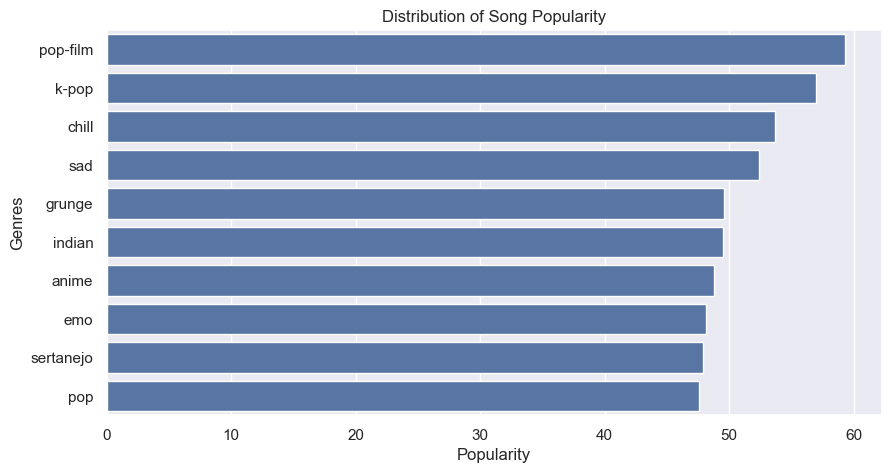

In [23]:
# Which genres have the most popular songs on average?

genre_popularity = df_clean.groupby('track_genre')['popularity'].mean()

#Top 10 
most_popular = genre_popularity.sort_values(ascending=False).head(10).reset_index()
print("Top 10", most_popular)

plt.figure(figsize=(10, 5))
sns.barplot(most_popular, x='popularity', y="track_genre")
plt.title("Top 10 Most Popular Genres on Spotify")
plt.xlabel("Popularity")
plt.ylabel("Genres")
plt.show()

> **Insight:** Pop-film (movie/TV soundtracks) ranks #1 — benefiting from exposure beyond Spotify. 
K-pop comes in 2nd, driven by highly organized global fanbases that actively stream to boost charts. 
Surprisingly, mood-based genres like "chill" and "sad" outperform mainstream "pop" itself.

## 🔥 Audio Feature Correlations
How do Spotify's audio features relate to each other? 
Values close to 1.0 mean features move together; values close to -1.0 mean they move in opposite directions.

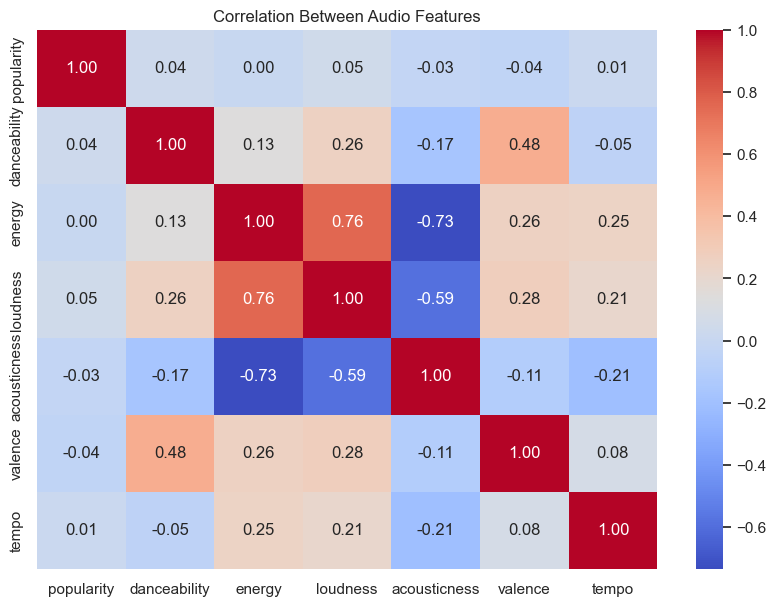

In [26]:
# How do audio features relate to each other
features = ['popularity', 'danceability', 'energy', 'loudness', 'acousticness', 'valence', 'tempo']

correlation_matrix = df_clean[features].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Between Audio Features")
plt.show()

> **Insight:** Energy and loudness are strongly correlated (0.76) — louder songs are almost always more energetic. 
The strongest negative correlation is between energy and acousticness (-0.73), 
meaning acoustic songs are nearly always low energy. 
Notably, popularity has near-zero correlation with every feature — 
no single audio trait predicts a hit song.

## 🔵 Energy vs Acousticness
Visualizing the strongest negative correlation in the dataset.

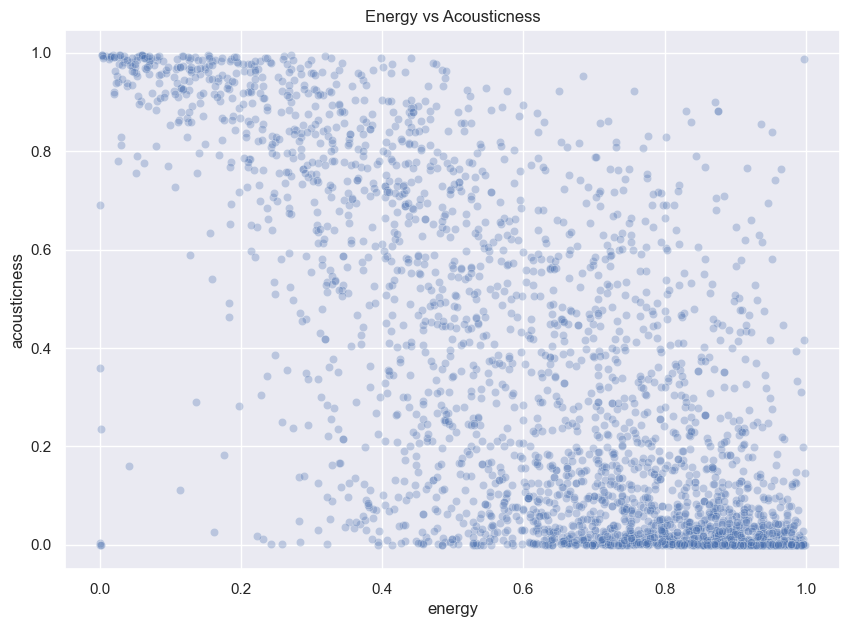

In [28]:
# Scatter Plot for Energy vs Acousticness

plt.figure(figsize=(10, 7))
sns.scatterplot(df_clean.sample(3000), x='energy', y='acousticness', alpha =0.3)
plt.title("Energy vs Acousticness")
plt.show()


> **Insight:** The scatter plot confirms the -0.73 correlation visually. 
Songs cluster in two zones — low energy/high acousticness (top-left) 
and high energy/low acousticness (bottom-right). 
The top-right quadrant (high energy AND highly acoustic) is nearly empty, 
confirming these traits are almost mutually exclusive.